In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision

import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

# ResUNet

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        
    def forward(self, x):
        return x + self.conv(x)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.resblock = ResidualBlock(out_channels)
        
    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.resblock(x)
        return x

In [ ]:
class Decoder(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(Decoder, self).__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.relu = nn.ReLU(inplace=True)        
        self.resblock = ResidualBlock(out_channels + skip_channels)

    def forward(self, x, skip):
        x = self.upconv(x)
        x = self.relu(x)
        if x.size()[2:] != skip.size()[2:]:
            x = F.interpolate(x, size=skip.size()[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.resblock(x)
        return x

In [ ]:
class ResUNet(nn.Module):
    def __init__(self):
        super(ResUNet, self).__init__()
        self.encoder1 = Encoder(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = Encoder(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = ResidualBlock(128)

        self.decoder2 = Decoder(128, 128, 128)
        self.decoder1 = Decoder(256, 64, 64)

        self.final_conv = nn.Conv2d(128, 3, kernel_size=1)

    def forward(self, x):
        skip1 = self.encoder1(x)
        x = self.pool1(skip1)
        skip2 = self.encoder2(x)
        x = self.pool2(skip2)

        x = self.bridge(x)

        x = self.decoder2(x, skip2)
        x = self.decoder1(x, skip1)

        x = self.final_conv(x)
        return x

In [ ]:
def imshow(img, title=""):
    """Utility function to show images"""
    img = img / 2 + 0.5 # Unnormalize
    npimg = img.cpu().numpy()
    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

In [ ]:
def train_resunet(model, device, train_loader, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = nn.MSELoss()(output, data)
            loss.backward()
            optimizer.step()
            
        print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize the images
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model = ResUNet().to(device)
optimizer = optim.Adam(model.parameters())

train_resunet(model, device, train_loader, optimizer, epochs=30)

current_time = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
torch.save(model.state_dict(), f'./model/resunet_trained_{current_time}.pth')

# Diffusion Model

In [ ]:
class DiffusionModel(nn.Module):
    def __init__(self, base_model, channels, num_steps=100, beta_min=0.1, beta_max=0.2, device=None):
        super(DiffusionModel, self).__init__()
        self.base_model = base_model
        self.num_steps = num_steps
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.beta_schedule = self.cosine_beta_schedule(num_steps, beta_min, beta_max).to(self.device)
        self.time_embedding = nn.Linear(1, channels).to(self.device)

    def cosine_beta_schedule(self, num_steps, beta_min, beta_max):
        steps = torch.linspace(0, num_steps, steps=num_steps, device=self.device)
        cosine_values = 0.5 * (1 + torch.cos(np.pi * steps / num_steps))
        return beta_min + (beta_max - beta_min) * cosine_values

    def forward(self, x):
        for step in range(self.num_steps):
            t = torch.full((x.size(0),), step, dtype=torch.long, device=x.device)
            beta_t = self.beta_schedule[t].unsqueeze(1).unsqueeze(2).unsqueeze(3)
            
            noise = torch.randn_like(x) * torch.sqrt(beta_t)

            x_noisy = x * torch.sqrt(1 - beta_t) + noise

            predicted_noise = self.base_model(x_noisy)

            x_recon = (x_noisy - predicted_noise) / torch.sqrt(1 - beta_t)
        
        return x_recon, x_noisy, noise, predicted_noise

    # def sample(self, shape):
    #     x = torch.randn(shape, device=self.device)
    #     for t in reversed(range(self.num_steps)):
    #         beta_t = self.beta_schedule[t].unsqueeze(0).unsqueeze(2).unsqueeze(3)
    #         predicted_noise = self.base_model(x)
    #         x = (x - torch.sqrt(beta_t) * predicted_noise) / torch.sqrt(1 - beta_t)
    #     return x
    
    def sample(self, shape):
        x = torch.randn(shape, device=self.device)  # Start with random noise
        images = [x]  # Collect images for animation
        for t in reversed(range(self.num_steps)):
            beta_t = self.beta_schedule[t].unsqueeze(0).unsqueeze(2).unsqueeze(3)
            predicted_noise = self.base_model(x)
            x = (x - torch.sqrt(beta_t) * predicted_noise) / torch.sqrt(1 - beta_t)
            images.append(x)
        return images  # Return the list of images for animation

In [ ]:
def refine_with_diffusion(base_model, device, data_loader, epochs=5, num_steps=1000, beta_min=0.1, beta_max=0.2):
    base_model.train()
    diffusion_model = DiffusionModel(base_model, channels=3, num_steps=num_steps, beta_min=beta_min, beta_max=beta_max)
    diffusion_model = diffusion_model.to(device)
    diffusion_model.train()
    optimizer = optim.Adam(diffusion_model.parameters(), lr=0.001)

    current_time = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    for epoch in range(epochs):
        for batch_idx, (data, _) in enumerate(data_loader):
            data = data.to(device)
            
            optimizer.zero_grad()
            reconstructed_data, x_noisy, noise, predicted_noise = diffusion_model(data)
            loss = torch.nn.functional.mse_loss(reconstructed_data, data)
            loss.backward()
            
            optimizer.step()

        print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

        torch.save(diffusion_model.state_dict(), f'./model/diffusion_trained_{current_time}_epoch{epoch+1}.pth')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained ResUNet
resunet_model = ResUNet()
resunet_model.load_state_dict(torch.load('model/resunet_trained_2024-06-21_01-02-10.pth'))
resunet_model = resunet_model.to(device)

refine_with_diffusion(resunet_model, device, train_loader, epochs=30, num_steps=100)

# Sample Generation

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image
import os

def load_test_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)
    return test_loader

def generate_and_save_images(model, device, test_loader, save_dir='generated_samples/'):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    with torch.no_grad():
        for i, (images, _) in enumerate(test_loader):
            images = images.to(device)
            reconstructed_images, _, _, _ = model(images)

            for j, (orig, recon) in enumerate(zip(images, reconstructed_images)):
                orig_save_path = f"{save_dir}original_{i*test_loader.batch_size + j:04d}.png"
                recon_save_path = f"{save_dir}reconstructed_{i*test_loader.batch_size + j:04d}.png"
                
                # Move images back to CPU for saving
                orig = orig.cpu()
                recon = recon.cpu()
                
                # Save the images
                save_image(orig, orig_save_path)
                save_image(recon, recon_save_path)

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_loader = load_test_data()

for epoch in range(5, 31, 5):
    base_model = ResUNet().to(device)
    base_model.load_state_dict(torch.load('model/resunet_trained_2024-06-21_01-02-10.pth'))

    model = DiffusionModel(base_model=base_model, channels=3, num_steps=100).to(device)
    model.load_state_dict(torch.load(f'model/diffusion_trained_2024-06-21_01-05-28_epoch{epoch}.pth'))

    generate_and_save_images(model, device, test_loader, save_dir=f'generated_samples/epoch{epoch:02d}/')

Files already downloaded and verified


# Denoising Animation

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image
import imageio
import os

def load_single_image():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    image, _ = dataset[1]  # Change index for different images
    return image.unsqueeze(0)  # Add batch dimension

def generate_denoising_animation(model, device, image, save_dir='denoising_process/'):
    os.makedirs(save_dir, exist_ok=True)
    images = [image.squeeze(0).cpu()]  # Save the original image for reference
    image = image.to(device)
    
    # Assuming the model's forward method is modified to yield intermediate outputs
    with torch.no_grad():
        for step, noisy_image in enumerate(model(image)):
            images.append(noisy_image.squeeze(0).cpu())
            save_image(noisy_image, f"{save_dir}step_{step:03d}.png")

    # Create GIF animation
    # print("len(images):", len(images))
    frames = [imageio.imread(f"{save_dir}step_{step:03d}.png") for step in range(len(images)-1)]
    imageio.mimsave(f"{save_dir}denoising_animation.gif", frames, fps=5)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_model = ResUNet().to(device)
base_model.load_state_dict(torch.load('model/resunet_trained_2024-06-21_01-02-10.pth'))

model = DiffusionModel(base_model=base_model, channels=3, num_steps=100).to(device)
model.load_state_dict(torch.load('model/diffusion_trained_2024-06-21_01-05-28_epoch30.pth'))

image = load_single_image()
generate_denoising_animation(model, device, image)

# SSIM

In [63]:
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from skimage import io, img_as_float
import numpy as np

def load_images(image_path1, image_path2):
    img1 = img_as_float(io.imread(image_path1))
    img2 = img_as_float(io.imread(image_path2))
    return img1, img2

def calculate_ssim(img1, img2):
    data_range = 1.0
    ssim_red = ssim(img1[:, :, 0], img2[:, :, 0], data_range=data_range)
    ssim_green = ssim(img1[:, :, 1], img2[:, :, 1], data_range=data_range)
    ssim_blue = ssim(img1[:, :, 2], img2[:, :, 2], data_range=data_range)
    ssim_value = (ssim_red + ssim_green + ssim_blue) / 3
    return ssim_value

Epoch : 5, SSIM : 0.833292158176297
Epoch : 10, SSIM : 0.837284647726763
Epoch : 15, SSIM : 0.8385671586822884
Epoch : 20, SSIM : 0.8416686380398766
Epoch : 25, SSIM : 0.842285031358589
Epoch : 30, SSIM : 0.8434951332060316


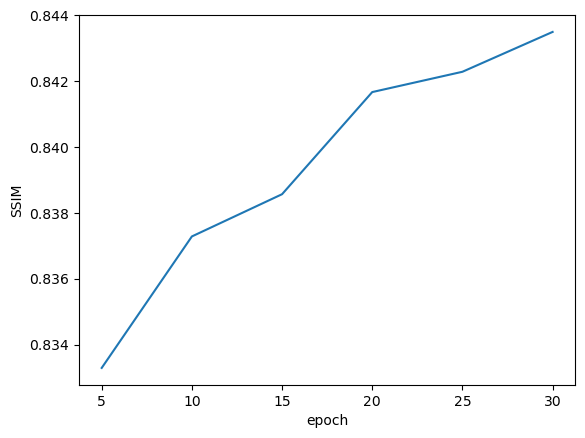

In [65]:
ssim_lst = []

for epoch in range(5, 31, 5):
    ssim_score = 0
    for i in range(10000):
        image_path1 = f'generated_samples/epoch{epoch:02d}/original_{i:04d}.png'
        image_path2 = f'generated_samples/epoch{epoch:02d}/reconstructed_{i:04d}.png'
        img1, img2 = load_images(image_path1, image_path2)

        ssim_score += calculate_ssim(img1, img2)

    ssim_score = ssim_score / 10000
    print(f'Epoch : {epoch}, SSIM : {ssim_score}')
    ssim_lst.append(ssim_score)

plt.plot([5, 10, 15, 20, 25, 30], ssim_lst)
plt.xlabel('epoch')
plt.ylabel('SSIM')
plt.show()

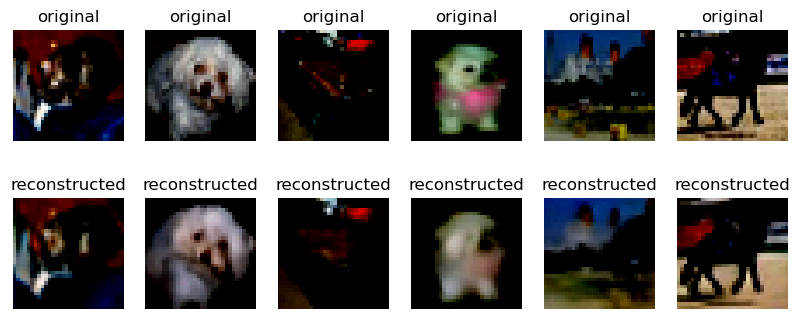

In [77]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display the images
fig, axes = plt.subplots(2, 6, figsize=(10, 4))

for i in range(0, 6):
    num = i * 1000

    image_path1 = f'generated_samples/epoch05/original_{num:04d}.png'
    image_path2 = f'generated_samples/epoch05/reconstructed_{num:04d}.png'

    img1 = mpimg.imread(image_path1)
    img2 = mpimg.imread(image_path2)

    ax1 = axes[0, i]
    ax2 = axes[1, i]

    ax1.imshow(img1)
    ax1.set_title('original')
    ax1.axis('off')

    ax2.imshow(img2)
    ax2.set_title('reconstructed')
    ax2.axis('off')

plt.show()